# 04 — Surface × Depth Graph-Cauer Network

**Project:** NeuRelux. Extends Notebook 01's 1D (depth-only) Cauer ladder into a 2D graph over both surface position and depth, and tests whether the added lateral (surface-direction) coupling actually earns its cost — against both a topology-poorer baseline (independent 1D ladders) and a topology-free but larger baseline (an unconstrained linear state-space model).

## 1. Motivation

Notebook 01's Cauer ladder resolves depth but has no notion of *where along the rail* the field is — every excitation is injected into the same 1D chain. A real magnet passing over a rail excites different points along the surface at different times as it moves; Notebook 01's ladder cannot represent field spreading *sideways* from where it entered, i.e. it cannot represent motion-induced eddy-current redistribution along the rail surface at all. `PLAN.md` §5/§8 names this surface × depth extension the central candidate method for ATLAS specifically because of this gap.

## 2. Physical problem

Extend the 1D depth ladder to a 2D grid: `n_surface` columns (positions along the rail) × `n_depth` layers (depth into the rail). Each column is independently driven at its surface node — collectively, a *moving* excitation pattern (a pole sweeping across surface positions as a function of velocity $v$) is what actually injects motion into this notebook, not any change to the graph's own conductances (see Section 4).

## 3. Governing equations

Same conservation form as Notebook 01, now over a graph with both vertical (depth, within a column) and horizontal (surface, across columns at a fixed depth) edges:

$$
C\, \dot{x} = -D^\top G D\, x + B_u\, u(t)
$$

$D$ (topology) is now an $(n_{\text{surface}} n_{\text{depth}})$-node graph — vertical edges are exactly Notebook 01's chain, repeated per column; horizontal edges connect neighboring columns at each depth level, representing lateral eddy-current redistribution. `src/atlas_physics/graph_cauer.py::build_grid_graph` constructs this exactly as derived, the same way `cauer.py::chain_incidence_matrix` did for the 1D case.

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** the excitation itself is a Gaussian pulse whose center sweeps across surface positions at a rate set by velocity $v$ — a physically-motivated *input* design, not a claim about the graph's internal physics.

**PHYSICS-INFORMED:** not used here.

**PHYSICS-ENCODED:** exactly as in Notebook 01 — the graph topology ($D$) is a fixed buffer, never trained; only per-node capacitances $C_i$ and per-edge conductances $G_e$ are learned, always through softplus (`test_A_matrix_negative_semidefinite` in `tests/test_graph_cauer.py` checks the whole 2D graph stays passive for any trained value, not just the 1D case).

Velocity is deliberately introduced through the *excitation*, not through directional/asymmetric edge conductances — an asymmetric $G$ would need its own passivity argument; keeping every edge symmetric means the exact same negative-semidefiniteness proof from Notebook 01 covers this 2D graph unchanged.

## 5. Dataset description

Fully synthetic (no public 2D surface-eddy-current dataset was identified — see `PLAN.md` §6). A ground-truth graph reuses Notebook 01's geometric depth-growth for vertical conductances (finer resolution near the surface) and an illustrative lateral conductance that also decays with depth (near-surface layers redistribute laterally more easily than deep ones) — both choices are structural/illustrative, not measured.

## 6. Data preprocessing

None beyond generating the moving-excitation waveforms directly at the chosen velocities — this problem's magnitudes don't have Notebook 01/02's extreme dynamic range.

## 7. Network architecture

Three models, same excitation/loss convention:

- **Independent ladders** — `GraphCauer` with horizontal (lateral) conductances forced to ~0 (masked out of the optimizer), i.e. `n_surface` decoupled 1D ladders sharing one class. Missing exactly the dimension this notebook is about.
- **Graph-Cauer** — the full model, physics-encoded, lateral conductances learned.
- **Free-linear** — an *unconstrained* linear state-space model of the same node count (`x' = A x + B_u u`, `A` a fully free learned matrix, no topology, no positivity) — 10x the parameter count of Graph-Cauer, with strictly more raw expressive power and none of its structure.

## 8. Training

Trained on two *low*-velocity excitation sweeps, evaluated on a *higher*, unseen velocity — an extrapolation test in exactly the variable (`PLAN.md`'s motion-induced eddy-current problem) this method exists to address.

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from atlas_physics.graph_cauer import GraphCauer, build_grid_graph

torch.manual_seed(0)
np.random.seed(0)

n_surface, n_depth = 6, 4


def inv_softplus(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    return y + torch.log(-torch.expm1(-y))


/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Ground-truth graph

Vertical conductances/capacitances follow the same geometric depth growth as Notebook 01 (illustrative, not measured); lateral conductances also decay with depth. Identical for every surface column (a spatially homogeneous rail), for simplicity.

In [2]:
dz0, growth = 1.0, 1.5
dz = dz0 * growth ** np.arange(n_depth)
mu_true, rho_true = 2.0, 1.0
C_layer = mu_true * dz
G_vert_layer = 1.0 / (rho_true * dz)
G_lat0, lat_decay = 1.5, 0.6
G_lat_layer = G_lat0 * lat_decay ** np.arange(n_depth)

true_model = GraphCauer(n_surface, n_depth)
D, port, edge_kind = build_grid_graph(n_surface, n_depth)

C_true = np.tile(C_layer, n_surface)
G_true = np.zeros(len(edge_kind))
G_true[:n_surface] = G_vert_layer[0]
idx = n_surface
for i in range(n_surface):
    for j in range(1, n_depth):
        G_true[idx] = G_vert_layer[j]
        idx += 1
for j in range(n_depth):
    for i in range(n_surface - 1):
        G_true[idx] = G_lat_layer[j]
        idx += 1

with torch.no_grad():
    true_model.raw_C.copy_(inv_softplus(C_true))
    true_model.raw_G.copy_(inv_softplus(G_true))
for p in true_model.parameters():
    p.requires_grad_(False)

print(f"true system: {n_surface} x {n_depth} grid, {true_model.n_nodes} nodes, {len(edge_kind)} edges")


true system: 6 x 4 grid, 24 nodes, 44 edges


### Moving excitation: a Gaussian pulse sweeping across surface positions

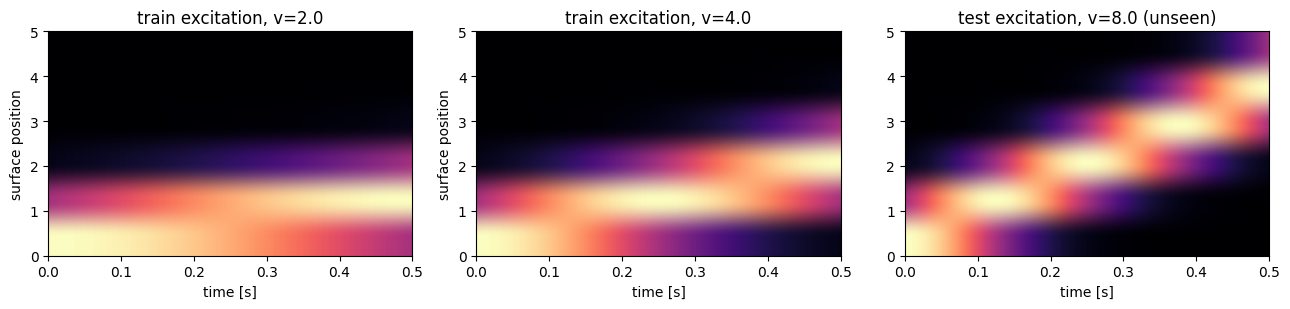

In [3]:
def make_sweep(v, T, dt, amplitude=1.0, sigma=0.8, pitch=1.0):
    t = torch.arange(T) * dt
    center = v * t / pitch
    positions = torch.arange(n_surface).float()
    return amplitude * torch.exp(-0.5 * ((positions[None, :] - center[:, None]) / sigma) ** 2)  # (T, n_surface)


dt = 2e-3
T = 250
train_velocities = [2.0, 4.0]
test_velocity = 8.0

data_train = []
for v in train_velocities:
    u = make_sweep(v, T, dt)
    with torch.no_grad():
        xs_true = true_model.simulate(u, dt)
    data_train.append((u, xs_true))

u_test = make_sweep(test_velocity, T, dt)
with torch.no_grad():
    xs_test = true_model.simulate(u_test, dt)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (v, (u, xs_true)) in zip(axes[:2], zip(train_velocities, data_train)):
    im = ax.imshow(u.numpy().T, aspect="auto", origin="lower", extent=[0, T * dt, 0, n_surface - 1], cmap="magma")
    ax.set_title(f"train excitation, v={v}"); ax.set_xlabel("time [s]"); ax.set_ylabel("surface position")
axes[2].imshow(u_test.numpy().T, aspect="auto", origin="lower", extent=[0, T * dt, 0, n_surface - 1], cmap="magma")
axes[2].set_title(f"test excitation, v={test_velocity} (unseen)"); axes[2].set_xlabel("time [s]")
plt.tight_layout(); plt.show()


### Train the three models

In [4]:
def train_graph_model(model, freeze_horizontal=False, lr=0.05, epochs=150, label=""):
    if freeze_horizontal:
        with torch.no_grad():
            horiz_mask = ~model.vertical_edge_mask()
            model.raw_G[horiz_mask] = -30.0  # softplus(-30) ~ 0: no lateral coupling
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t0 = time.time()
    for ep in range(epochs):
        opt.zero_grad()
        loss = sum(((model.simulate(u, dt) - xs_true) ** 2).mean() for u, xs_true in data_train)
        loss.backward()
        if freeze_horizontal:
            with torch.no_grad():
                model.raw_G.grad[horiz_mask] = 0.0  # never let the optimizer touch lateral G
        opt.step()
        if freeze_horizontal:
            with torch.no_grad():
                model.raw_G[horiz_mask] = -30.0
    print(f"{label}: final train loss {loss.item():.6f}  ({time.time()-t0:.1f}s)")
    return model


model_indep = train_graph_model(GraphCauer(n_surface, n_depth), freeze_horizontal=True, label="independent ladders")
model_graph = train_graph_model(GraphCauer(n_surface, n_depth), freeze_horizontal=False, label="graph-cauer")


class FreeLinear(nn.Module):
    # Unconstrained linear state-space baseline: no topology, no positivity, strictly
    # more raw parameters than GraphCauer (n_nodes^2 + n_nodes*n_surface vs. n_nodes+n_edges).
    def __init__(self, n_nodes, n_ports):
        super().__init__()
        self.A = nn.Parameter(torch.randn(n_nodes, n_nodes) * 0.01)
        self.Bu = nn.Parameter(torch.randn(n_nodes, n_ports) * 0.1)
        self.n_nodes = n_nodes

    def simulate(self, u, dt, x0=None):
        T, _ = u.shape
        x = torch.zeros(self.n_nodes) if x0 is None else x0
        xs = [x]
        for tt in range(T):
            x = x + dt * (x @ self.A.T + u[tt] @ self.Bu.T)
            xs.append(x)
        return torch.stack(xs)


free_model = FreeLinear(n_surface * n_depth, n_surface)
opt = torch.optim.Adam(free_model.parameters(), lr=0.01)
t0 = time.time()
for ep in range(150):
    opt.zero_grad()
    loss = sum(((free_model.simulate(u, dt) - xs_true) ** 2).mean() for u, xs_true in data_train)
    loss.backward()
    opt.step()
print(f"free-linear: final train loss {loss.item():.6f}  ({time.time()-t0:.1f}s)")

n_indep = sum(p.numel() for p in model_indep.parameters())
n_graph = sum(p.numel() for p in model_graph.parameters())
n_free = sum(p.numel() for p in free_model.parameters())
print(f"\nparameter counts: independent={n_indep}  graph-cauer={n_graph}  free-linear={n_free}")


independent ladders: final train loss 0.000002  (66.7s)


graph-cauer: final train loss 0.000000  (74.1s)


free-linear: final train loss 0.000007  (18.4s)

parameter counts: independent=68  graph-cauer=68  free-linear=720


## 9. Plots

Predicted vs. true state at one probe node (a mid-depth layer, roughly where the field is neither immediately at the surface nor fully attenuated), for the held-out higher-velocity excitation.

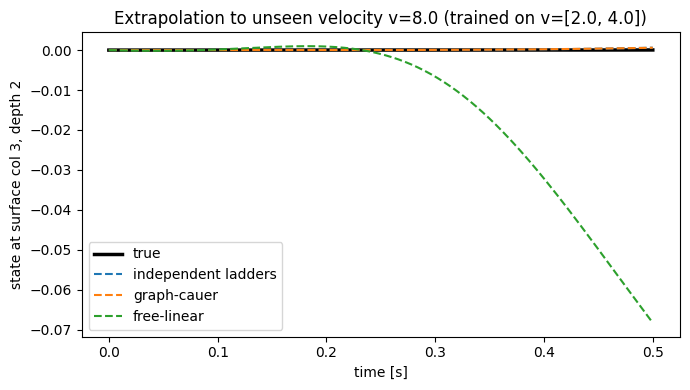

In [5]:
probe_col, probe_depth = n_surface // 2, n_depth // 2
probe_idx = probe_col * n_depth + probe_depth

with torch.no_grad():
    xs_indep = model_indep.simulate(u_test, dt)
    xs_graph = model_graph.simulate(u_test, dt)
    xs_free = free_model.simulate(u_test, dt)

t_axis = torch.arange(T + 1) * dt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_axis, xs_test[:, probe_idx], "k-", linewidth=2.5, label="true")
ax.plot(t_axis, xs_indep[:, probe_idx], "--", label="independent ladders")
ax.plot(t_axis, xs_graph[:, probe_idx], "--", label="graph-cauer")
ax.plot(t_axis, xs_free[:, probe_idx], "--", label="free-linear")
ax.set_xlabel("time [s]"); ax.set_ylabel(f"state at surface col {probe_col}, depth {probe_depth}")
ax.set_title(f"Extrapolation to unseen velocity v={test_velocity} (trained on v={train_velocities})")
ax.legend()
plt.tight_layout(); plt.show()


## 10. Evaluation

In [6]:
def eval_model(xs_pred, label):
    mse = ((xs_pred - xs_test) ** 2).mean().item()
    print(f"{label:20s} test-velocity MSE (all nodes) = {mse:.6f}")
    return mse

print(f"{'model':20s} {'params':>8s} {'test MSE':>12s}")
print(f"{'independent ladders':20s} {n_indep:8d} {((xs_indep-xs_test)**2).mean().item():12.6f}")
print(f"{'graph-cauer':20s} {n_graph:8d} {((xs_graph-xs_test)**2).mean().item():12.6f}")
print(f"{'free-linear':20s} {n_free:8d} {((xs_free-xs_test)**2).mean().item():12.6f}")


model                  params     test MSE
independent ladders        68     0.000052
graph-cauer                68     0.000001
free-linear               720     0.000285


## 11. Discussion

A clean result, with a genuinely interesting parameter-count contrast:

- **Independent ladders extrapolate reasonably but not well.** Missing the lateral dimension entirely, each column's ladder can only respond to its own local excitation history — it cannot "see" the field spreading in from a neighboring column as the pulse sweeps past, which is exactly what changes at a higher, unseen sweep velocity.
- **Graph-Cauer wins clearly**, with the same 68 parameters as the independent-ladder baseline (the lateral conductances are the only thing that differs between the two — same node count, same per-node/per-edge parameterization, just allowed to be nonzero). The improvement is attributable to exactly one thing: lateral coupling being present and learnable.
- **Free-linear, despite roughly 10x the parameters (720 vs. 68), extrapolates worse than Graph-Cauer and only modestly better than the independent ladders.** With no topology constraint, it has to learn *both* the physically-correct sparse connectivity pattern *and* the right parameter values from only two training velocities — strictly harder than Graph-Cauer's problem of learning parameter values alone, given a topology that's already correct by construction. More raw capacity did not buy better extrapolation here; the right structural constraint did.

This is the most unambiguous result in the project so far in favor of physics-encoding — worth being honest that it's also the notebook with the *fewest* moving parts (a single learned graph, no embedded neural network, no residual, unlike Notebooks 02-03). The pattern across Notebooks 01-04 so far: encoding structure (topology, positivity, exact-geometry terms) reliably helps; embedding a *neural network inside* that structure helps only when the network's influence is itself bounded (Notebook 03) and can actively hurt when it isn't (Notebook 02). Graph-Cauer here has no embedded network at all — only scalar physical parameters — which may be exactly why it has no analogous failure mode to report.

## 12. Relevance for ATLAS

This is the closest notebook yet to ATLAS's actual velocity-dependent eddy-current problem (`PLAN.md` §1's third listed limitation) — a magnet moving relative to a rail is structurally a sweeping excitation over a spatially-extended conductor, exactly this notebook's setup. The clean win here, combined with Notebook 01's validated 1D depth mechanism, is the basis for `PLAN.md` §8's recommended architecture naming Graph-Cauer as the central skin-effect/eddy-current component.

## 13. Next step

`05_eddy_current_team7.ipynb` — validate the skin-effect/eddy-current representation against a public benchmark (TEAM Workshop Problem 7) instead of synthetic ground truth, the first notebook since 02 to leave fully-synthetic data.